# Part 1: Single-Agent Strategic Allocation Analysis

This notebook analyzes the results from Part 1 experiments comparing three token allocation strategies:
- **Deep Thinker (80/20)**: More reasoning, less output
- **Balanced (50/50)**: Equal allocation
- **Verbose (20/80)**: Less reasoning, more output

## Objectives
1. Compare token usage patterns across strategies
2. Analyze response quality metrics
3. Examine tool usage behavior
4. Identify optimal allocation strategies for different task types

## Setup

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

## Load Data

In [2]:
# Find the most recent results file
results_dir = Path("../experiments/results")
result_files = sorted(results_dir.glob("part1_results_*.json"), reverse=True)

if not result_files:
    raise FileNotFoundError(
        "No experiment results found. Please run experiments first."
    )

latest_results = result_files[0]
print(f"Loading: {latest_results.name}")

with open(latest_results) as f:
    data = json.load(f)

metadata = data["metadata"]
results = pd.DataFrame(data["results"])

print("\nMetadata:")
print(f"  Budget: {metadata['total_budget']} tokens")
print(f"  Tasks: {metadata['num_tasks']}")
print(f"  Strategies: {metadata['num_strategies']}")
print(f"  Total experiments: {len(results)}")

Loading: part1_results_20251116_204907.json

Metadata:
  Budget: 5000 tokens
  Tasks: 1
  Strategies: 3
  Total experiments: 3


In [3]:
# Display first few rows
results.head()

,task_id,strategy,question,response_preview,response_length,reasoning_tokens_used,output_tokens_used,total_tokens_used,total_tool_calls,tool_usage_details,duration_seconds,quality_completeness,quality_clarity,quality_depth,quality_evidence,quality_overall
0,simple_01,deep,What is quantum computing and what are its mai...,**Defining Quantum Computing**\n\nI've initiat...,334,0,726,726,3,"[{'tool': 'google_search', 'calls': 3, 'tokens...",4.883517,3.5,10.0,1.902174,0.0,3.850543
1,simple_01,balanced,What is quantum computing and what are its mai...,**Seeking Quantum Definition & Apps**\n\nI've ...,321,0,425,425,2,"[{'tool': 'google_search', 'calls': 2, 'tokens...",4.410317,4.5,10.0,1.093750,0.0,3.898438
2,simple_01,verbose,What is quantum computing and what are its mai...,**Delving into Quantum Computing**\n\nI've ini...,564,0,1591,1591,2,"[{'tool': 'google_search', 'calls': 2, 'tokens...",7.943424,4.5,10.0,2.243590,0.0,4.185897


## Summary Statistics

In [4]:
# Group by strategy
strategy_summary = results.groupby("strategy").agg(
    {
        "total_tokens_used": ["mean", "std", "min", "max"],
        "reasoning_tokens_used": ["mean", "std"],
        "output_tokens_used": ["mean", "std"],
        "total_tool_calls": ["mean", "std"],
        "duration_seconds": ["mean", "std"],
        "quality_overall": ["mean", "std"],
        "quality_completeness": "mean",
        "quality_clarity": "mean",
        "quality_depth": "mean",
        "quality_evidence": "mean",
    }
)

print("\n=" * 80)
print("STRATEGY COMPARISON SUMMARY")
print("=" * 80)
print(strategy_summary.round(2))


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
STRATEGY COMPARISON SUMMARY
         total_tokens_used                 reasoning_tokens_used      \
                      mean std   min   max                  mean std   
strategy                                                               
balanced             425.0 NaN   425   425                   0.0 NaN   
deep                 726.0 NaN   726   726                   0.0 NaN   
verbose             1591.0 NaN  1591  1591                   0.0 NaN   

         output_tokens_used     total_tool_calls     duration_seconds      \
                       mean std             mean std             mean std   
strategy                                                                    
balanced              425.0 NaN              2.0 NaN             4.41 NaN   
deep                  726.0 NaN              3.0 NaN             4.88 

## Token Allocation Analysis

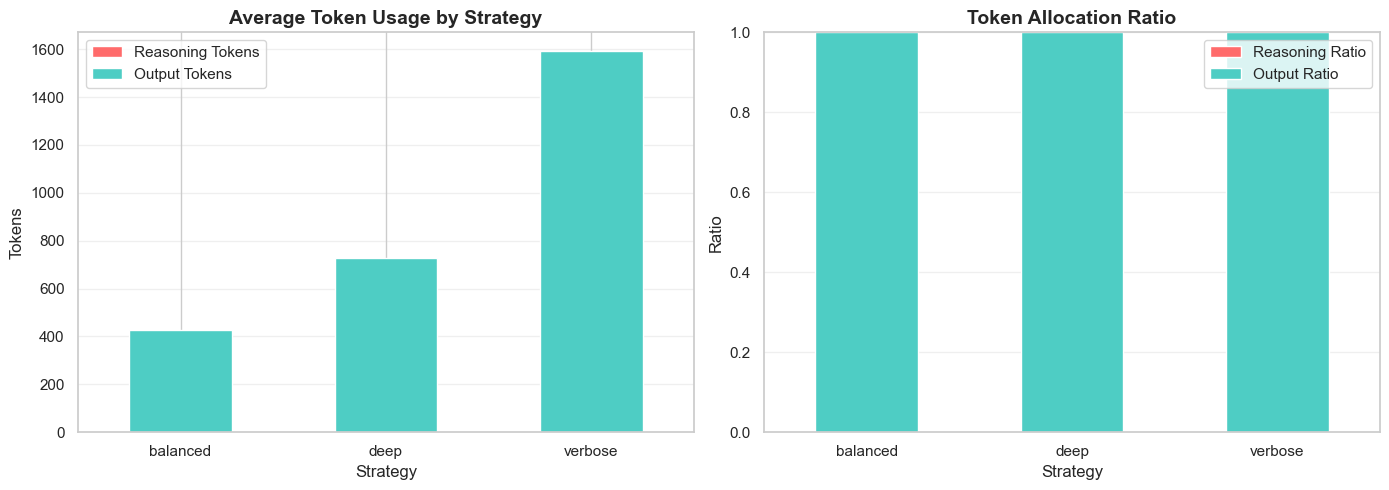

In [5]:
# Calculate allocation ratios
results["reasoning_ratio"] = (
    results["reasoning_tokens_used"] / results["total_tokens_used"]
)
results["output_ratio"] = results["output_tokens_used"] / results["total_tokens_used"]

# Create allocation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Token usage by strategy
token_data = results.groupby("strategy")[
    ["reasoning_tokens_used", "output_tokens_used"]
].mean()
token_data.plot(kind="bar", stacked=True, ax=axes[0], color=["#FF6B6B", "#4ECDC4"])
axes[0].set_title("Average Token Usage by Strategy", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Strategy")
axes[0].set_ylabel("Tokens")
axes[0].legend(["Reasoning Tokens", "Output Tokens"])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Allocation ratio
ratio_data = results.groupby("strategy")[["reasoning_ratio", "output_ratio"]].mean()
ratio_data.plot(kind="bar", stacked=True, ax=axes[1], color=["#FF6B6B", "#4ECDC4"])
axes[1].set_title("Token Allocation Ratio", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Strategy")
axes[1].set_ylabel("Ratio")
axes[1].legend(["Reasoning Ratio", "Output Ratio"])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../experiments/results/token_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

## Quality Metrics Analysis

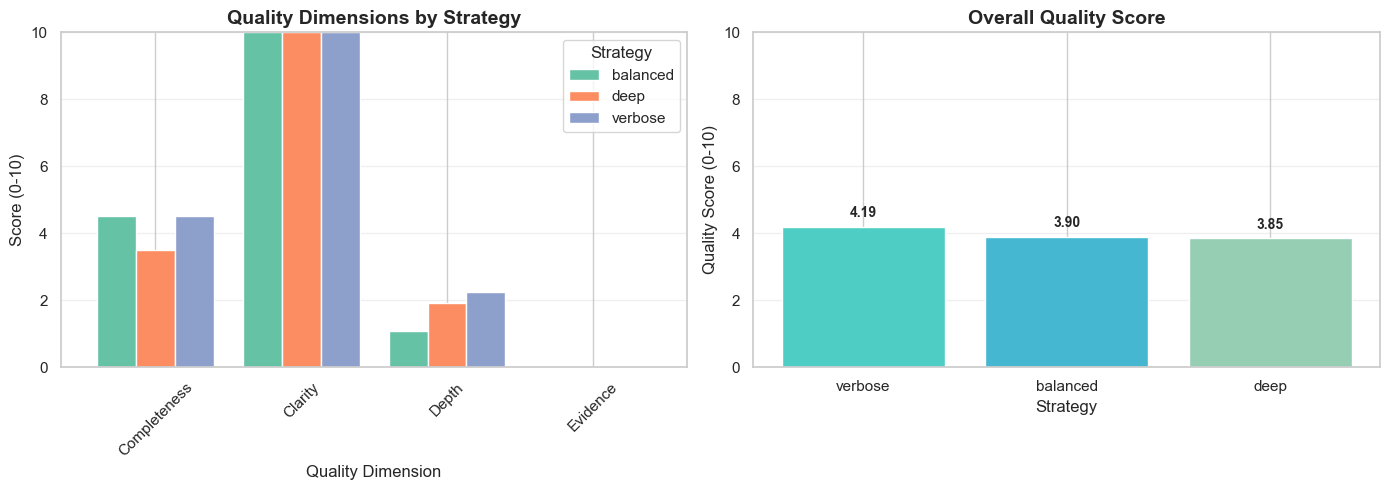

In [6]:
# Quality dimensions comparison
quality_cols = [
    "quality_completeness",
    "quality_clarity",
    "quality_depth",
    "quality_evidence",
]
quality_data = results.groupby("strategy")[quality_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Quality dimensions
quality_data.T.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Quality Dimensions by Strategy", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Quality Dimension")
axes[0].set_ylabel("Score (0-10)")
axes[0].legend(title="Strategy", loc="upper right")
axes[0].set_xticklabels(["Completeness", "Clarity", "Depth", "Evidence"], rotation=45)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim(0, 10)

# Plot 2: Overall quality score
overall_quality = (
    results.groupby("strategy")["quality_overall"].mean().sort_values(ascending=False)
)
bars = axes[1].bar(
    range(len(overall_quality)),
    overall_quality.values,
    color=["#4ECDC4", "#45B7D1", "#96CEB4"],
)
axes[1].set_title("Overall Quality Score", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Strategy")
axes[1].set_ylabel("Quality Score (0-10)")
axes[1].set_xticks(range(len(overall_quality)))
axes[1].set_xticklabels(overall_quality.index, rotation=0)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 10)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, overall_quality.values)):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../experiments/results/quality_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Tool Usage Analysis

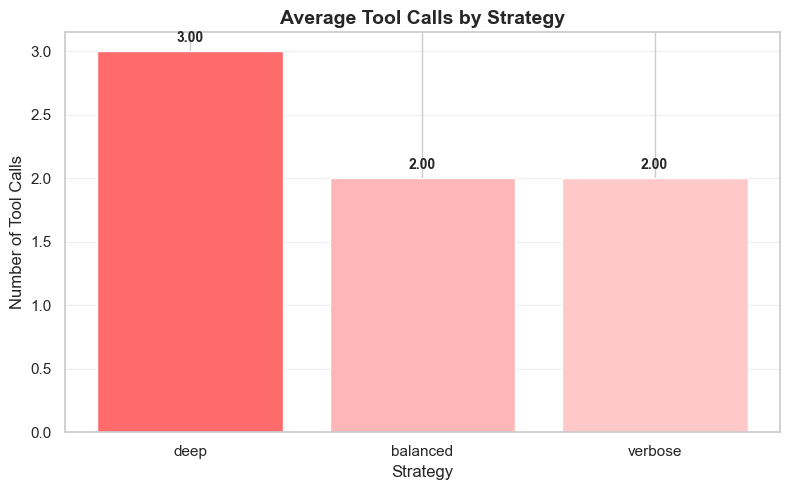

In [7]:
# Tool usage comparison
tool_usage = (
    results.groupby("strategy")["total_tool_calls"].mean().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    range(len(tool_usage)), tool_usage.values, color=["#FF6B6B", "#FFB6B9", "#FFC9C9"]
)
ax.set_title("Average Tool Calls by Strategy", fontsize=14, fontweight="bold")
ax.set_xlabel("Strategy")
ax.set_ylabel("Number of Tool Calls")
ax.set_xticks(range(len(tool_usage)))
ax.set_xticklabels(tool_usage.index, rotation=0)
ax.grid(axis="y", alpha=0.3)

# Add value labels
for bar, value in zip(bars, tool_usage.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../experiments/results/tool_usage.png", dpi=300, bbox_inches="tight")
plt.show()

## Efficiency Analysis

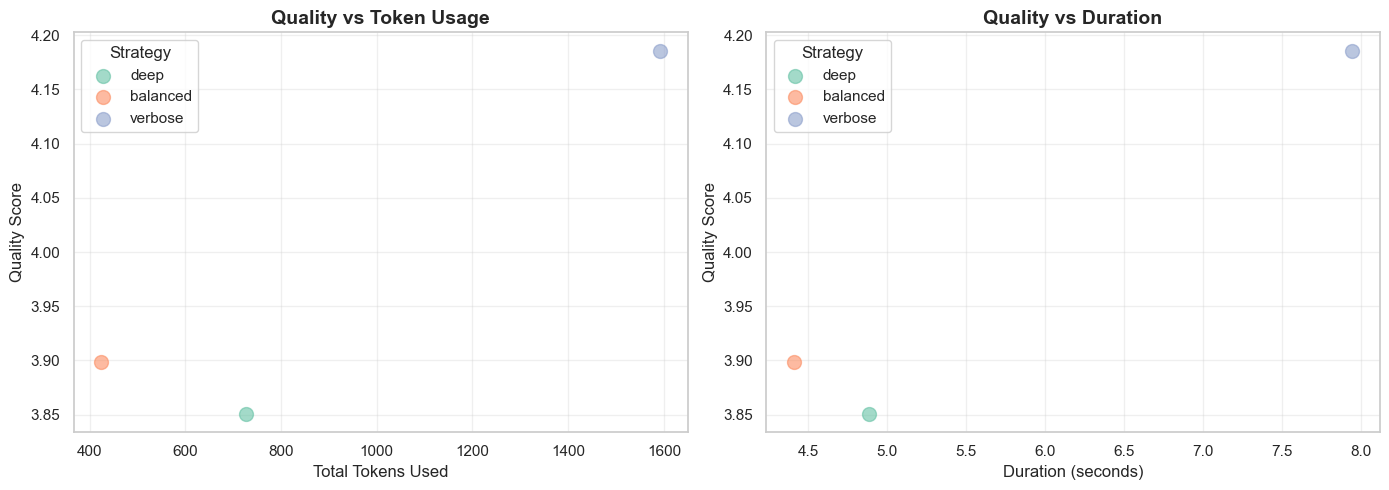

In [8]:
# Quality vs Token Usage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Quality vs Tokens
for strategy in results["strategy"].unique():
    strategy_data = results[results["strategy"] == strategy]
    axes[0].scatter(
        strategy_data["total_tokens_used"],
        strategy_data["quality_overall"],
        label=strategy,
        s=100,
        alpha=0.6,
    )

axes[0].set_title("Quality vs Token Usage", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Total Tokens Used")
axes[0].set_ylabel("Quality Score")
axes[0].legend(title="Strategy")
axes[0].grid(True, alpha=0.3)

# Plot 2: Quality vs Duration
for strategy in results["strategy"].unique():
    strategy_data = results[results["strategy"] == strategy]
    axes[1].scatter(
        strategy_data["duration_seconds"],
        strategy_data["quality_overall"],
        label=strategy,
        s=100,
        alpha=0.6,
    )

axes[1].set_title("Quality vs Duration", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Duration (seconds)")
axes[1].set_ylabel("Quality Score")
axes[1].legend(title="Strategy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../experiments/results/efficiency_analysis.png", dpi=300, bbox_inches="tight"
)
plt.show()

## Detailed Comparison Table

In [9]:
# Create comprehensive comparison table
comparison = (
    results.groupby("strategy")
    .agg(
        {
            "total_tokens_used": "mean",
            "reasoning_tokens_used": "mean",
            "output_tokens_used": "mean",
            "total_tool_calls": "mean",
            "duration_seconds": "mean",
            "quality_overall": "mean",
            "quality_completeness": "mean",
            "quality_clarity": "mean",
            "quality_depth": "mean",
            "quality_evidence": "mean",
        }
    )
    .round(2)
)

comparison.columns = [
    "Tokens (Total)",
    "Tokens (Reasoning)",
    "Tokens (Output)",
    "Tool Calls",
    "Duration (s)",
    "Quality (Overall)",
    "Quality (Complete)",
    "Quality (Clarity)",
    "Quality (Depth)",
    "Quality (Evidence)",
]

print("\n" + "=" * 120)
print("COMPREHENSIVE STRATEGY COMPARISON")
print("=" * 120)
print(comparison.to_string())
print("=" * 120)


COMPREHENSIVE STRATEGY COMPARISON
          Tokens (Total)  Tokens (Reasoning)  Tokens (Output)  Tool Calls  Duration (s)  Quality (Overall)  Quality (Complete)  Quality (Clarity)  Quality (Depth)  Quality (Evidence)
strategy                                                                                                                                                                              
balanced           425.0                 0.0            425.0         2.0          4.41               3.90                 4.5               10.0             1.09                 0.0
deep               726.0                 0.0            726.0         3.0          4.88               3.85                 3.5               10.0             1.90                 0.0
verbose           1591.0                 0.0           1591.0         2.0          7.94               4.19                 4.5               10.0             2.24                 0.0


## Key Findings

In [10]:
# Calculate efficiency metrics
best_quality = results.groupby("strategy")["quality_overall"].mean().idxmax()
best_efficiency = (
    results.groupby("strategy")["quality_overall"].mean()
    / results.groupby("strategy")["total_tokens_used"].mean()
).idxmax()
fastest = results.groupby("strategy")["duration_seconds"].mean().idxmin()
most_thorough = results.groupby("strategy")["total_tool_calls"].mean().idxmax()

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print(f"\n✨ Best Quality:           {best_quality}")
print(f"⚡ Best Efficiency:         {best_efficiency} (quality per token)")
print(f"🚀 Fastest Execution:       {fastest}")
print(f"🔍 Most Thorough Research:  {most_thorough} (tool calls)")
print("\n" + "=" * 80)


KEY FINDINGS

✨ Best Quality:           verbose
⚡ Best Efficiency:         balanced (quality per token)
🚀 Fastest Execution:       balanced
🔍 Most Thorough Research:  deep (tool calls)



## Export Summary Report

In [11]:
# Save summary to CSV
comparison.to_csv("../experiments/results/part1_summary.csv")
print("Summary saved to: experiments/results/part1_summary.csv")

# Save detailed results to CSV
results.to_csv("../experiments/results/part1_detailed.csv", index=False)
print("Detailed results saved to: experiments/results/part1_detailed.csv")

Summary saved to: experiments/results/part1_summary.csv
Detailed results saved to: experiments/results/part1_detailed.csv
